# Quantum Capacitance

This notebook walks through the new `compute_quantum_capacitance`
and `fit_quantum_capacitance` methods on the `QPD` class. It mirrors
the step-by-step style of `qpd.ipynb`: derive the quantity from the
Hamiltonian, plot it, then fit a synthetic "measured" trace.


In [1]:
%matplotlib inline
from qpd import QPD
import numpy as np
import matplotlib.pyplot as plt

qpd = QPD(e_j_hz=8.335e9, e_c_hz=0.695e9)  # E_J/E_C ~ 12 (WashU)


# From energy levels to quantum capacitance

The QPD Hamiltonian we already diagonalize in `qpd.ipynb` gives, for
each parity branch, a ground-state energy $E_0(n_g)$ that depends
smoothly on the dimensionless offset charge $n_g$. The qubit
responds to a small change in the gate voltage $V_g = 2e\, n_g / C_g$
by adjusting its bound charge — a differential capacitance:

$$
C_Q \;\equiv\; -\frac{\partial^2 E_0}{\partial V_g^2}
        \;=\; -\left(\frac{C_g}{2e}\right)^2
              \frac{\partial^2 E_0}{\partial n_g^2}.
$$

With energies expressed in Hz, the explicit factor of $h$ shows up:

$$
C_Q[\mathrm{F}] \;=\; -\left(\frac{C_g}{2e}\right)^2 h\,
                    \frac{\partial^2 E_0[\mathrm{Hz}]}{\partial n_g^2}.
$$

The package computes this directly from the numerical eigenvalues —
no asymptotic approximation. The shape of $C_Q(n_g)$ encodes
$E_J/E_C$, while the absolute amplitude is set by the gate-coupling
prefactor.


## Compute it for both parities

Even parity is solved at $n_g$, odd parity at $n_g + 1/2$ (the
single-quasiparticle shift). `compute_quantum_capacitance` returns
both branches at once.


In [2]:
ng = np.linspace(0, 2, 401)
cq_e_hz, cq_o_hz = qpd.compute_quantum_capacitance(ng)  # Hz units
print('intrinsic peak |dE^2/dn_g^2|:',
      f'even = {np.max(np.abs(cq_e_hz))/1e6:.2f} MHz,',
      f'odd = {np.max(np.abs(cq_o_hz))/1e6:.2f} MHz')


intrinsic peak |dE^2/dn_g^2|: even = 67.79 MHz, odd = 67.79 MHz


If you prefer Farads and you know the gate capacitance, pass it as
`c_g_f`. Here we use a synthetic 1 fF gate capacitance just for
illustration.


In [3]:
cq_e_F, cq_o_F = qpd.compute_quantum_capacitance(ng, c_g_f=1e-15)
print(f'with C_g = 1 fF, peak C_Q = {np.max(np.abs(cq_o_F))*1e21:.2f} zF')


with C_g = 1 fF, peak C_Q = 437.43 zF


## Plot the trace

The companion plotter `plot_quantum_capacitance` mirrors the styling
of the other `plot_*` methods. Without `c_g_f` it labels the
y-axis as the intrinsic curvature in GHz; with `c_g_f` it switches
to fF.


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': '$\\xi=12.0$, $E_J=8.34$ GHz, $E_C=0.695$ GHz'}, xlabel='Offset Charge [$C_g V_g / 2e$]', ylabel='$-\\partial^2 E / \\partial n_g^2$ [GHz]'>)

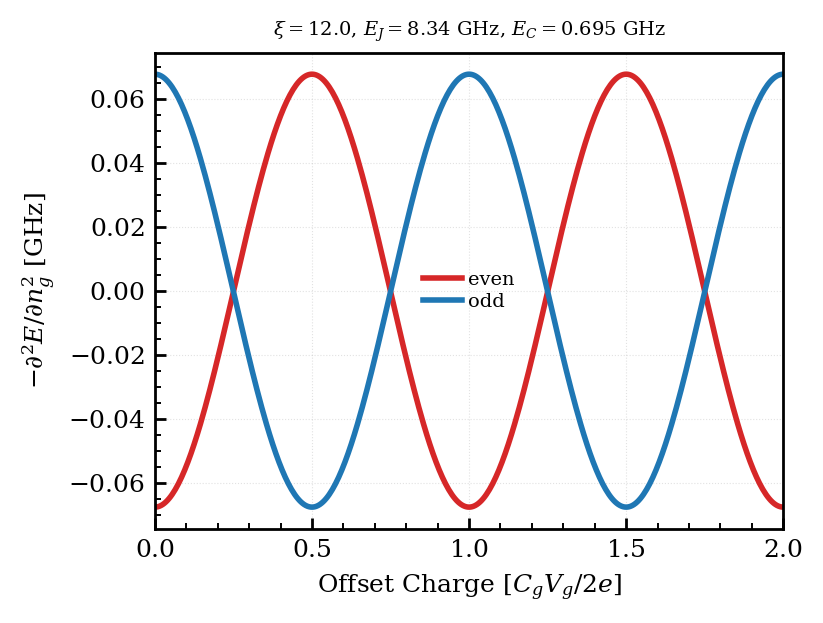

In [4]:
qpd.plot_quantum_capacitance(ng)


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': '$\\xi=12.0$, $E_J=8.34$ GHz, $E_C=0.695$ GHz'}, xlabel='Offset Charge [$C_g V_g / 2e$]', ylabel='$C_Q$ [fF]'>)

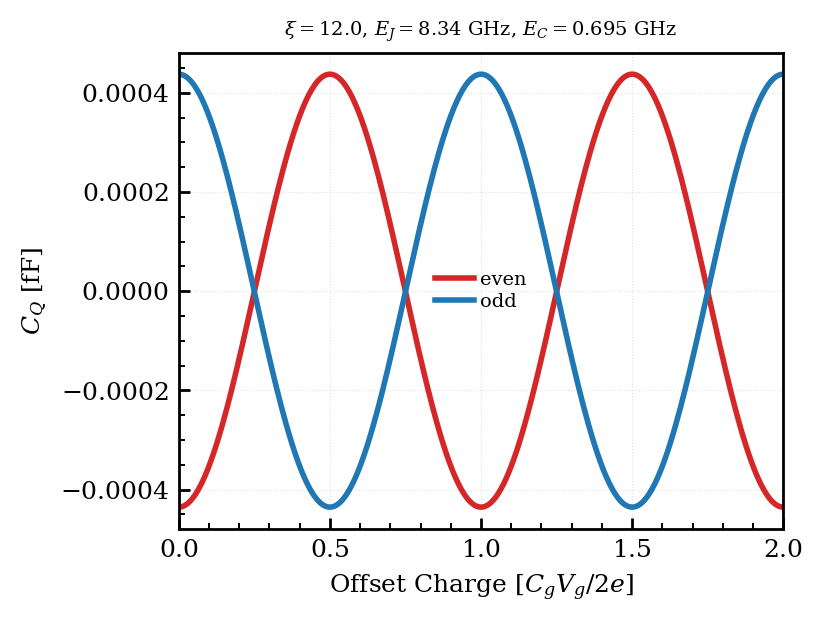

In [5]:
qpd.plot_quantum_capacitance(ng, c_g_f=1e-15)


## How the shape depends on $E_J/E_C$

Sweeping the ratio shows the two intuitive limits:

- $E_J/E_C \to \infty$ (deep transmon): charge dispersion is
  exponentially suppressed, so $C_Q(n_g)$ flattens.
- $E_J/E_C \to 0$ (Cooper-pair box): charge dispersion is large
  and $C_Q$ develops sharp peaks at $n_g = 0.5$ (even) and
  $n_g = 0$ (odd).


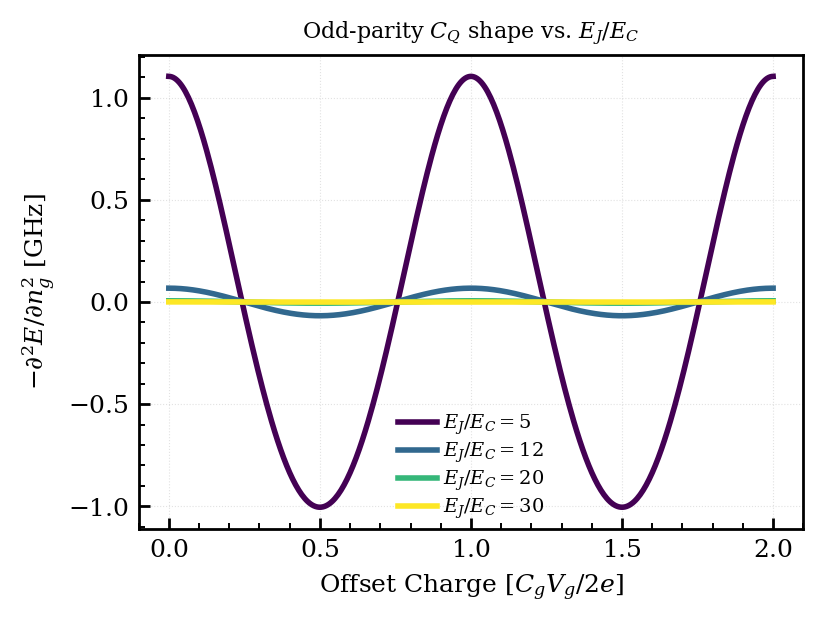

In [6]:
ratios = [5, 12, 20, 30]
e_c_hz = 0.695e9
with plt.style.context(QPD._style_path):
    fig, ax = plt.subplots(figsize=(4, 3))
    cmap = plt.colormaps.get_cmap('viridis')
    for k, r in enumerate(ratios):
        q = QPD(e_j_hz=r * e_c_hz, e_c_hz=e_c_hz)
        _, cq_o = q.compute_quantum_capacitance(ng)
        ax.plot(ng, cq_o / 1e9, color=cmap(k / (len(ratios) - 1)),
                linewidth=2, label=f'$E_J/E_C={r}$')
    ax.set_xlabel(r'Offset Charge [$C_g V_g / 2e$]')
    ax.set_ylabel(r'$-\partial^2 E / \partial n_g^2$ [GHz]')
    ax.set_title('Odd-parity $C_Q$ shape vs. $E_J/E_C$', fontsize=8)
    ax.legend(fontsize=7)
    ax.minorticks_on(); ax.grid(alpha=0.3)
    plt.show()


# Fitting a measured trace

In practice we measure $C_Q$ as a function of $n_g$ — typically via
a phase-shift readout (see `readout_inversion.ipynb`) — and want
to extract the device parameters that produced it. Following
issue #4 we fit four quantities:

- $E_J$, $E_C$ — the qubit energies (the asymptotic Eq. 5 in
  arXiv:0902.4194 is *not* used; we fit the numerical curve);
- $n_{g,0}$ — a charge offset, in case the measurement axis is not
  perfectly centred;
- `scale` — an overall amplitude that absorbs any unknown
  prefactor (so you don't need to know $C_g$ to fit the shape).

Below we generate a synthetic measurement, then run the fit.


In [7]:
ej_true, ec_true, ng0_true = 8.335e9, 0.695e9, 0.05
truth = QPD(e_j_hz=ej_true, e_c_hz=ec_true)

# Use a fine 1-period grid for the fit. The numerical 2nd
# derivative inside the fitter is sensitive to dn, so a denser
# grid keeps the chi^2 valley well-resolved. The visualisation
# grid `ng' (covering 2 periods, used above) is independent.
ng_fit = np.linspace(0, 1, 401)
_, cq_truth = truth.compute_quantum_capacitance(ng_fit - ng0_true)

rng = np.random.default_rng(0)
# 0.05 % per-point noise. The chi^2 valley along the (E_J, E_C)
# weak-shape direction is shallow; with much more noise the
# individual E_J / E_C values can drift by tens of percent even
# while the ratio stays tight.
noise = rng.normal(0, 5e-4 * np.max(np.abs(cq_truth)),
                   size=ng_fit.size)
cq_meas = cq_truth + noise


Start the fit from a *deliberately wrong* initial guess so we can
see the optimiser do real work. Because the synthetic data is in
intrinsic units (Hz), we know the true `scale` is 1 — fixing it
with `fit_scale=False` breaks the (E_C, scale) shape/amplitude
degeneracy and lets the fit pin $E_J$ and $E_C$ tightly.


In [8]:
guess = QPD(e_j_hz=1.1 * ej_true, e_c_hz=0.9 * ec_true)
fit = guess.fit_quantum_capacitance(
    ng_fit, cq_meas, parity='odd', fit_scale=False, fixed_scale=1.0,
)

# Tabulate results with error (if available), error as percentile (relative to true value), and true values
import pandas as pd

true_vals = {
    'e_j_hz': ej_true,
    'e_c_hz': ec_true,
    'n_g0': ng0_true,
    'ej_ec_ratio': ej_true / ec_true,
    'scale': 1.0,
}

rows = []
for key in ('e_j_hz', 'e_c_hz', 'n_g0', 'ej_ec_ratio', 'scale'):
    val = fit.get(key, None)
    err = fit.get('errors', {}).get(key, None)
    true = true_vals.get(key, None)
    # Compute error percent if possible and true is not zero
    if true and abs(true) > 0:
        err_pct = (abs(val - true) / abs(true)) * 100.0 if (val is not None and true is not None) else None
    else:
        err_pct = None
    rows.append({
        'name': key,
        'fitted': f"{val:.5g}" if val is not None else "",
        'error': f"{err:.2g}" if err is not None else "",
        'error [%]': f"{err_pct:.2f}" if err_pct is not None else "",
        'true': f"{true:.5g}" if true is not None else "",
    })

df = pd.DataFrame(rows, columns=["name", "fitted", "error", "error [%]", "true"])
print(df.to_string(index=False))


       name     fitted   error error [%]      true
     e_j_hz 8.2645e+09 1.6e+07      0.85 8.335e+09
     e_c_hz 6.9028e+08 1.1e+06      0.68  6.95e+08
       n_g0   0.050006 8.2e-05      0.01      0.05
ej_ec_ratio     11.973              0.17    11.993
      scale          1       0      0.00         1


(<Figure size 800x800 with 2 Axes>,
 (<Axes: title={'center': '$E_J/E_C=11.97$, $E_J=8.264$ GHz, $E_C=0.6903$ GHz, $n_{g0}=+0.050$'}, ylabel='$C_Q$ [Hz]'>,
  <Axes: xlabel='Offset Charge [$C_g V_g / 2e$]', ylabel='residual [Hz]'>))

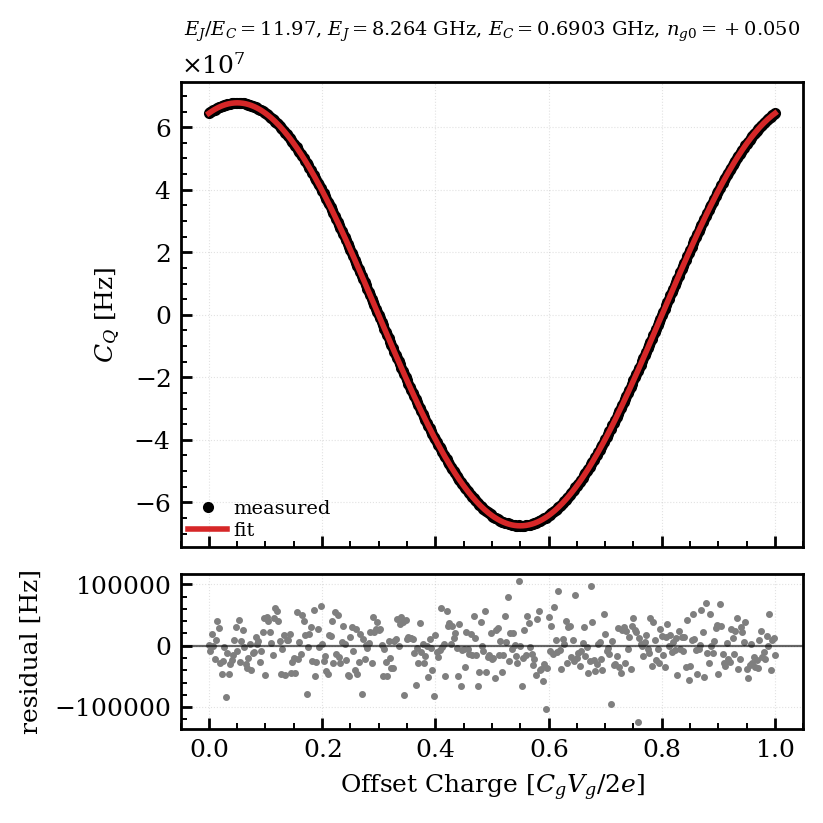

In [9]:
qpd.plot_capacitance_fit(ng_fit, cq_meas, fit)


## A note on noise sensitivity

The C_Q(n_g) curve in the QPD/transmon regime is nearly a pure
cosine — its *shape* depends only weakly on E_J/E_C, and the
absolute amplitude carries most of the information about the
energies. As a result the chi² valley in (E_J, E_C) space is
extremely shallow: with realistic 1 % noise the fit's individual
E_J and E_C values can drift by ~10 % along this valley while
the chi² stays at the noise floor. The **ratio** E_J/E_C, the
n_g offset, and the product `scale · E_C` remain well-determined.
If you need absolute energies in this regime, supplement the
C_Q fit with an independent measurement (e.g. anharmonicity
α ≈ -E_C from spectroscopy) to break the valley degeneracy.


## When the absolute amplitude is unknown

If your measurement is in Farads but $C_g$ is uncertain, leave
`fit_scale=True` (the default). The fitter will absorb any unknown
prefactor into `scale`. The **shape** parameters $E_J/E_C$ and
$n_{g,0}$ remain identifiable; the absolute split between $E_C$
and `scale` becomes degenerate, so report the ratio rather than
the individual energies in that mode.


In [10]:
fit_loose = guess.fit_quantum_capacitance(
    ng_fit, cq_meas, parity='odd', fit_scale=True,
)
print('Free-scale fit:')
print(f'  E_J/E_C  = {fit_loose["ej_ec_ratio"]:.3f}  (truth {ej_true/ec_true:.3f})')
print(f'  n_g0     = {fit_loose["n_g0"]:+.4f}  (truth {ng0_true:+.4f})')
print(f'  scale    = {fit_loose["scale"]:.4g}')
print(f'  RMS resid (relative) = '
      f'{np.sqrt(np.mean(fit_loose["residuals"]**2)) / np.max(np.abs(cq_meas)):.3%}')


Free-scale fit:
  E_J/E_C  = 12.101  (truth 11.993)
  n_g0     = +0.0500  (truth +0.0500)
  scale    = 1.651
  RMS resid (relative) = 0.050%


In short:

- Use `fit_scale=False, fixed_scale=...` whenever the
  data has been pre-converted to a known absolute convention.
- Use `fit_scale=True` (default) when only the trace shape is
  trustworthy; rely on `ej_ec_ratio` and `n_g0` from the result.


## Visualising the chi² landscape

The shallow-valley caveat above is easier to *see* than to argue
about. `plot_likelihood_landscape` evaluates chi² on an (E_J, E_C)
grid around the fit point (with n_g0 and scale held at their
fitted values) and overlays the 1σ / 2σ / 3σ joint-coverage
contours plus the constant-ratio line through the fit. A long
narrow valley along the constant-ratio line means the ratio is
well-determined but the individual energies are degenerate; a
round basin means both are tight.


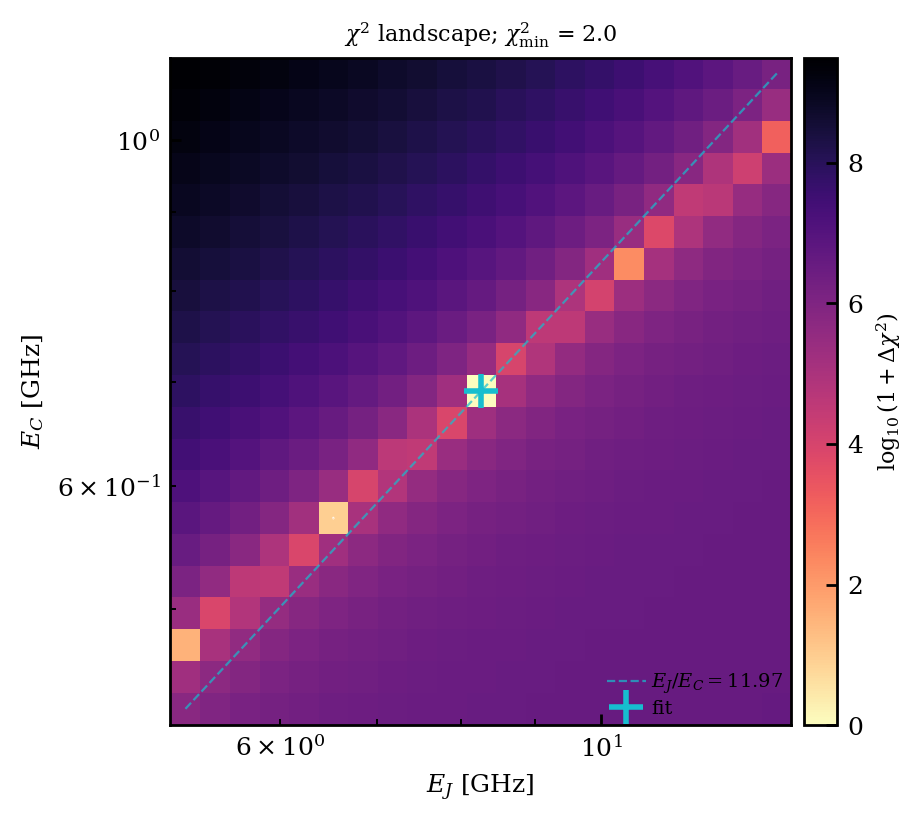

In [11]:
fig, ax = qpd.plot_likelihood_landscape(
    ng_fit, cq_meas, fit, parity='odd',
    n_grid=21, span_factor=1.6,
)
